In [1]:
import sys
sys.dont_write_bytecode = True
%load_ext autoreload
%autoreload 1
%aimport classify_dice
import classify_dice
from ultralytics import YOLO
import sklearn
import cv2
from matplotlib import pyplot as plt
import numpy as np
import einops

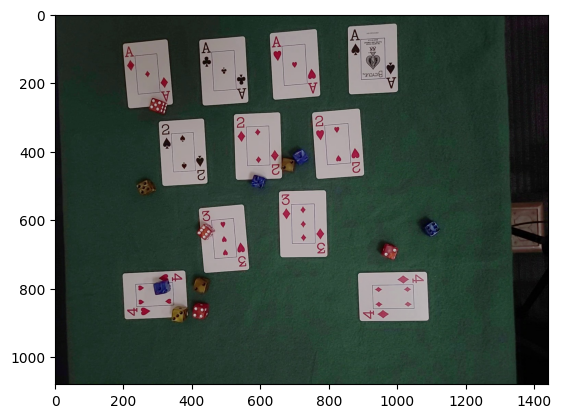

In [2]:
obb_model = YOLO("model/rdg_obb/weights/best.pt")

example_frame = "data/frames/frame_0214.jpg"
img = cv2.imread(example_frame)
classify_dice.imshow(img)

In [4]:
res = obb_model(img, task='obb')[0]
res


0: 384x512 12 dies, 4 aces, 3 twos, 2 threes, 2 fours, 5.8ms
Speed: 1.5ms preprocess, 5.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 512)


ultralytics.engine.results.Results object with attributes:

boxes: None
keypoints: None
masks: None
names: {0: 'die', 1: 'ace', 2: 'two', 3: 'three', 4: 'four'}
obb: ultralytics.engine.results.OBB object
orig_img: array([[[20, 25, 23],
        [21, 26, 24],
        [29, 33, 28],
        ...,
        [33, 26, 31],
        [28, 21, 24],
        [21, 14, 17]],

       [[18, 23, 21],
        [19, 24, 22],
        [28, 32, 27],
        ...,
        [32, 25, 30],
        [28, 21, 24],
        [23, 16, 19]],

       [[17, 22, 20],
        [17, 22, 20],
        [27, 31, 26],
        ...,
        [30, 23, 28],
        [27, 20, 25],
        [24, 17, 22]],

       ...,

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [11, 11,

In [5]:
res[0].obb

ultralytics.engine.results.OBB object with attributes:

cls: tensor([3.], device='cuda:0')
conf: tensor([0.9655], device='cuda:0')
data: tensor([[493.3746, 653.5643, 200.1789, 129.4977,   1.5234,   0.9655,   3.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 1440)
shape: torch.Size([1, 7])
xywhr: tensor([[493.3746, 653.5643, 200.1789, 129.4977,   1.5234]], device='cuda:0')
xyxy: tensor([[423.9603, 550.5220, 562.7888, 756.6066]], device='cuda:0')
xyxyxyxy: tensor([[[433.4363, 756.6066],
         [562.7888, 750.4764],
         [553.3128, 550.5220],
         [423.9603, 556.6521]]], device='cuda:0')
xyxyxyxyn: tensor([[[0.3010, 0.7006],
         [0.3908, 0.6949],
         [0.3842, 0.5097],
         [0.2944, 0.5154]]], device='cuda:0')

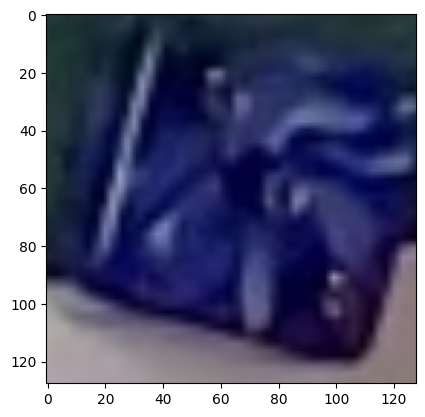

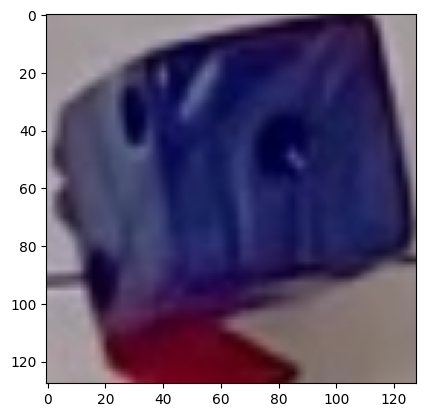

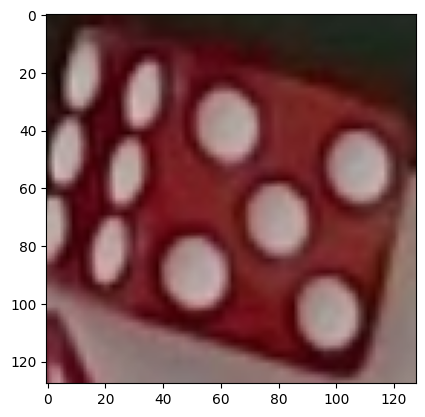

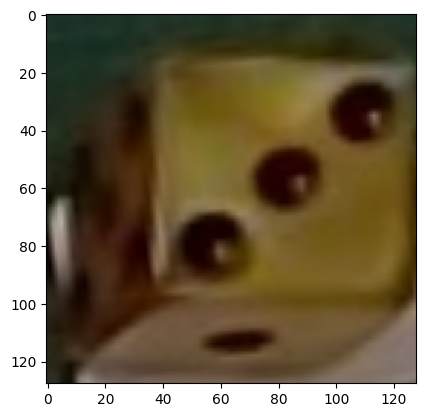

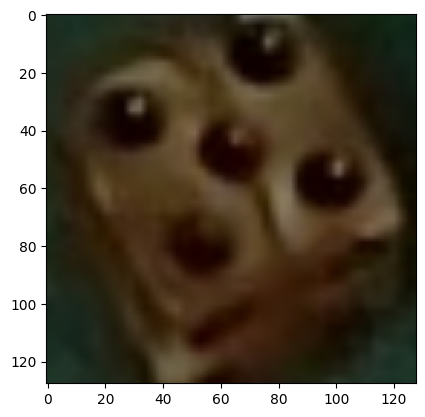

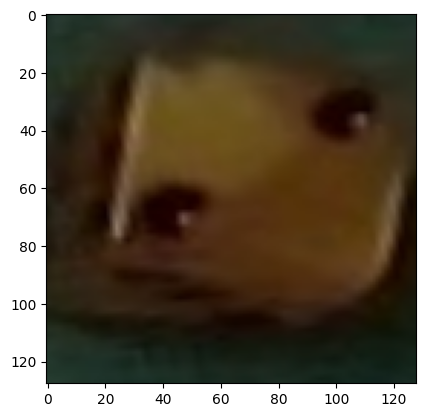

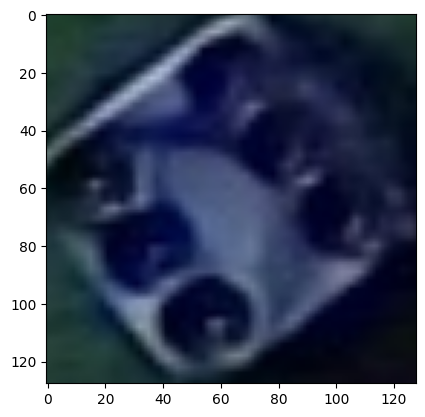

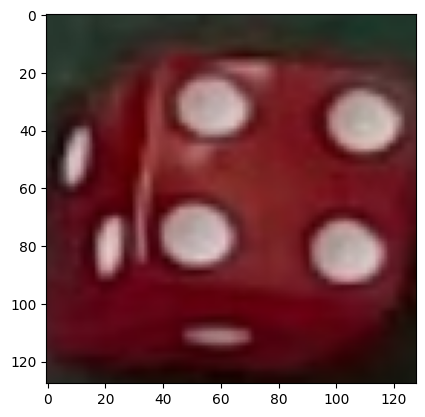

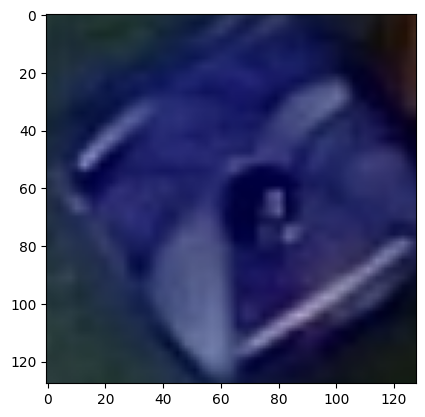

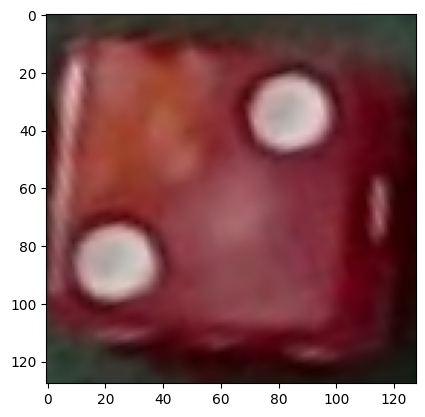

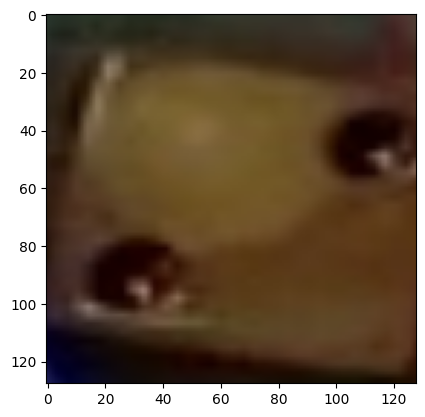

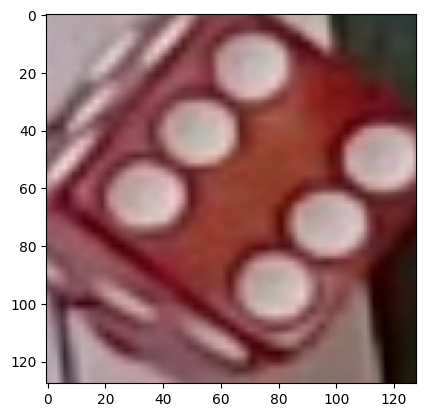

In [6]:
dice_cropped = classify_dice.batch_crop_dice(img, res)

for die_idx in range(dice_cropped.shape[0]):
    plt.figure()
    classify_dice.imshow(dice_cropped[die_idx,:,:,:])

In [8]:
k_means,palette = classify_dice.kmeans_color(dice_cropped)

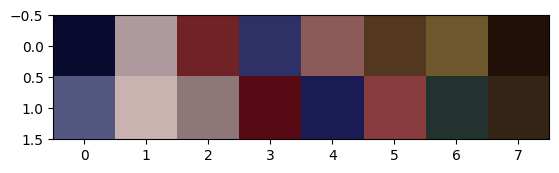

In [9]:
classify_dice.imshow(einops.rearrange(palette, "(h w) C -> h w C", w=8))

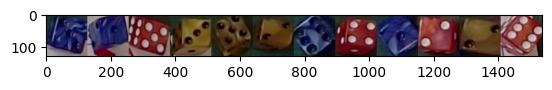

In [10]:
classify_dice.imshow(einops.rearrange(dice_cropped, "N H W C-> H (N W) C"))

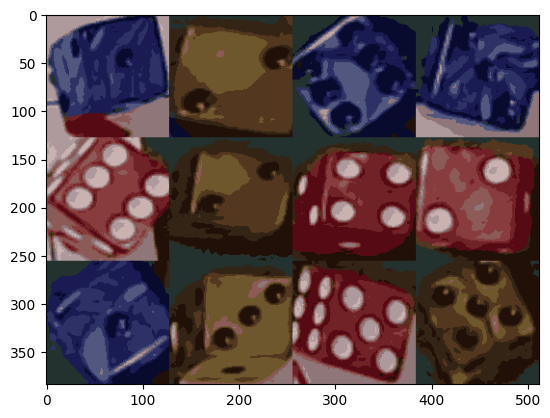

(973, 128, 128, 3)


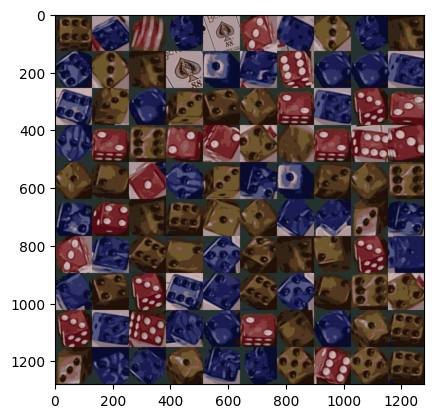

In [11]:
# recolor dice using this limited palette


classes,posterized = classify_dice.posterize(dice_cropped, k_means, palette)
sample_idxs = np.random.permutation(posterized.shape[0])[:100]
plt.figure()
classify_dice.imshow(einops.rearrange(posterized[sample_idxs,...], "(N x) H W C -> (N H) (x W) C", x=4))
plt.show()

# all_dice = classify_dice.generate_dice_dataset(obb_model)
all_dice = np.load('data/dice/all_dice.npz')['arr_0']
print(all_dice.shape)
_,all_dice_posterized = classify_dice.posterize(all_dice, k_means, palette)
sample_idxs = np.random.permutation(all_dice_posterized.shape[0])[:100]
plt.figure()
classify_dice.imshow(einops.rearrange(all_dice_posterized[sample_idxs,...], "(N x) H W C -> (N H) (x W) C", x=10))
plt.show()


In [88]:
limgs,lids,lplayers,lvalues = classify_dice.load_labeled_dice()

In [ ]:
# classify_dice.imshow(einops.rearrange(limgs[lplayers==0,:,:,:], "N H W C -> "))

EinopsError:  Error while processing rearrange-reduction pattern "N H W C -> ".
 Input tensor shape: (43, 128, 128, 3). Additional info: {}.
 Identifiers only on one side of expression (should be on both): {'N', 'C', 'H', 'W'}

In [ ]:
img

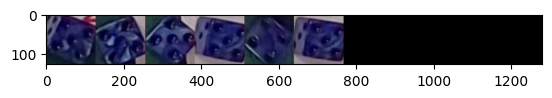

In [86]:
mask=(lplayers==2)&(lvalues==5)
classify_dice.show_imgs_grid(limgs[mask], width=10)

lids[bad_idx]=np.int64(532)


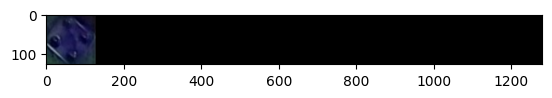

In [87]:
bad_idx = np.argwhere(np.cumsum(mask)==5)[0,0]
print(f"{lids[bad_idx]=}")
classify_dice.show_imgs_grid(limgs[[bad_idx],:,:,:])

np.int64(760)

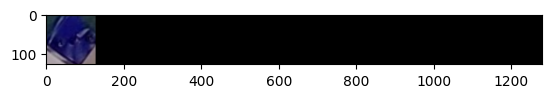

In [43]:
classify_dice.show_imgs_grid(limgs[[154],:,:,:])
lids[154]

In [ ]:
np.savez_compressed('data/dice/all_dice.npz', all_dice.astype(np.uint8))

In [ ]:
classify_dice.write_dice()

{3, 518, 9, 522, 523, 12, 13, 526, 15, 11, 17, 20, 532, 24, 25, 537, 538, 28, 541, 30, 544, 545, 34, 546, 46, 559, 47, 566, 56, 57, 576, 579, 67, 69, 581, 71, 585, 587, 83, 600, 89, 602, 94, 95, 96, 610, 99, 615, 104, 105, 106, 107, 619, 625, 115, 628, 631, 632, 633, 638, 126, 127, 639, 643, 644, 134, 652, 147, 148, 155, 667, 670, 672, 675, 164, 682, 171, 172, 170, 173, 175, 176, 692, 181, 694, 696, 697, 187, 699, 704, 706, 198, 200, 713, 202, 720, 209, 722, 217, 731, 732, 737, 741, 742, 239, 752, 241, 753, 244, 757, 758, 248, 760, 765, 258, 259, 777, 778, 266, 273, 275, 787, 277, 281, 282, 283, 796, 284, 798, 288, 804, 809, 302, 307, 821, 823, 312, 317, 325, 837, 846, 855, 345, 349, 862, 863, 356, 357, 362, 874, 365, 877, 883, 884, 885, 376, 380, 384, 387, 388, 903, 904, 392, 906, 909, 401, 915, 406, 407, 408, 409, 412, 415, 418, 934, 425, 938, 941, 431, 950, 951, 442, 957, 447, 961, 452, 455, 457, 972, 462, 465, 482, 485, 486, 487, 488, 499, 502, 505, 507}
